# ResNet-50 | Training from Scratch
Multi-label clothing classification - 5 classes  
Loss: BCEWithLogitsLoss + pos_weight | Init: Kaiming (PyTorch default) | Threshold: 0.5

## 1. Configuration

In [ ]:
import os, glob, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm



BASE_DIR = '/kaggle/input/datasets/fashion/processed'

TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train', 'images')
VAL_IMG_DIR   = os.path.join(BASE_DIR, 'validation', 'images')

print(f'Dataset root : {BASE_DIR}')
print(f'Train images : {TRAIN_IMG_DIR}')
print(f'Val   images : {VAL_IMG_DIR}')

BATCH_SIZE          = 64
NUM_CLASSES         = 5
NUM_EPOCHS          = 30      
LR                  = 1e-3
WEIGHT_DECAY        = 1e-4
PATIENCE            = 5       
THRESHOLD           = 0.5
CKPT                = '/kaggle/working/resnet50_scratch_best.pth'
CLASS_NAMES         = ['short_sleeve_top', 'trousers', 'shorts',
                        'long_sleeve_top', 'skirt']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')

## 2. Load Labels

In [ ]:
with open(os.path.join(BASE_DIR, 'train_labels.pkl'), 'rb') as f:
    train_labels = pickle.load(f)
with open(os.path.join(BASE_DIR, 'val_labels.pkl'), 'rb') as f:
    val_labels = pickle.load(f)

train_arr = np.array(list(train_labels.values()))

print(f'Train: {len(train_labels):,}  |  Val: {len(val_labels):,}')
print('\nClass positives in train:')
for i, c in enumerate(CLASS_NAMES):
    p = int(train_arr[:, i].sum())
    print(f'  {c:<20}: {p:>6}  ({p/len(train_arr)*100:.1f}%)')

Train: 144,174  |  Val: 23,741

Class positives in train:
  short_sleeve_top    :  70586  (49.0%)
  trousers            :  54969  (38.1%)
  shorts              :  36332  (25.2%)
  long_sleeve_top     :  35751  (24.8%)
  skirt               :  30625  (21.2%)


## 3. Dataset & DataLoader
Transforms are necessary: ResNet-50 requires 224×224 fixed input.  
Train: random crop + horizontal flip (standard augmentation, nothing excessive).  
Val: deterministic resize + centre crop.

In [23]:
from PIL import Image
import os
from tqdm.notebook import tqdm

def preprocess_split(src_dir, dst_dir, size=(224, 224)):
    os.makedirs(dst_dir, exist_ok=True)
    files = os.listdir(src_dir)
    for fname in tqdm(files, desc=f'Resizing {os.path.basename(src_dir)}'):
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        if os.path.exists(dst):
            continue
        Image.open(src).convert('RGB').resize(size, Image.BILINEAR).save(dst)

TRAIN_IMG_DIR_224 = '/kaggle/working/train_224'
VAL_IMG_DIR_224   = '/kaggle/working/val_224'

preprocess_split(TRAIN_IMG_DIR, TRAIN_IMG_DIR_224)
preprocess_split(VAL_IMG_DIR,   VAL_IMG_DIR_224)

Resizing images:   0%|          | 0/144174 [00:00<?, ?it/s]

Resizing images:   0%|          | 0/23741 [00:00<?, ?it/s]

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.io import read_image, ImageReadMode

class FashionDataset(Dataset):
    def __init__(self, labels_dict, img_root, transform=None):
        self.labels = labels_dict
        self.filenames = list(labels_dict.keys())
        self.transform = transform
        self.img_root = img_root

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, i):
        fname = self.filenames[i]
        img_path = os.path.join(self.img_root, fname)

        # Faster than PIL on many setups
        img = read_image(img_path, mode=ImageReadMode.RGB).float() / 255.0

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(self.labels[fname], dtype=torch.float32)
        return img, label


_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=_mean, std=_std),
])

val_tf = transforms.Compose([
    transforms.Normalize(mean=_mean, std=_std),
])


train_ds = FashionDataset(train_labels, TRAIN_IMG_DIR_224, train_tf)
val_ds   = FashionDataset(val_labels,   VAL_IMG_DIR_224,   val_tf)

print(f"Train images: {len(train_ds)}")
print(f"Val images: {len(val_ds)}")

NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)
print("Batch label shape:", yb.shape)
print("Image dtype:", xb.dtype)
print("Label dtype:", yb.dtype)

Train images: 144174
Val images: 23741
Train batches: 2253 | Val batches: 371
Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64, 5])
Image dtype: torch.float32
Label dtype: torch.float32


## 4. Model
`weights=None` - Kaiming init (PyTorch default for ResNet conv layers).  
FC replaced: 2048 → 5 (one logit per class). No sigmoid here - it lives inside BCEWithLogitsLoss.

In [26]:
model = resnet50(weights=None)
model.fc = nn.Linear(2048, NUM_CLASSES)
nn.init.kaiming_normal_(model.fc.weight, mode='fan_out', nonlinearity='relu')
nn.init.constant_(model.fc.bias, 0.0)
model = model.to(device)
model = torch.compile(model)

print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable params: 23,518,277


## 5. Loss, Optimizer & Scheduler
`pos_weight[i] = neg_i / pos_i` - correct formula for BCEWithLogitsLoss.  
This up-weights positive samples for minority classes (skirt pos_weight ≈ 3.71).

In [27]:
pos        = train_arr.sum(axis=0)                    # (5,)
neg        = len(train_arr) - pos
pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(device)

print('pos_weight per class:')
for name, w in zip(CLASS_NAMES, pos_weight.cpu().tolist()):
    print(f'  {name:<20}: {w:.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

pos_weight per class:
  short_sleeve_top    : 1.043
  trousers            : 1.623
  shorts              : 2.968
  long_sleeve_top     : 3.033
  skirt               : 3.708


## 6. Evaluation Function

In [ ]:
def evaluate(model, loader, criterion=None):
    model.eval()
    probs_list, labels_list = [], []
    total_vloss = 0.0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs_d, lbls_d = imgs.to(device), lbls.to(device)
            logits = model(imgs_d)
            probs_list.append(torch.sigmoid(logits).cpu().numpy())
            labels_list.append(lbls.numpy())
            if criterion:
                total_vloss += criterion(logits, lbls_d).item() * imgs.size(0)

    probs  = np.vstack(probs_list)   
    labels = np.vstack(labels_list)  
    preds  = (probs >= THRESHOLD).astype(int)

    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = int(((preds[:,i]==1) & (labels[:,i]==1)).sum())
        fp = int(((preds[:,i]==1) & (labels[:,i]==0)).sum())
        tn = int(((preds[:,i]==0) & (labels[:,i]==0)).sum())
        fn = int(((preds[:,i]==0) & (labels[:,i]==1)).sum())
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2*prec*rec / (prec + rec + 1e-8)
        auc  = roc_auc_score(labels[:,i], probs[:,i])
        per_class[cls] = dict(TP=tp, FP=fp, TN=tn, FN=fn,
                               Precision=prec, Recall=rec, F1=f1, AUC=auc)

    macro_f1 = float(np.mean([v['F1'] for v in per_class.values()]))
    ttp = sum(v['TP'] for v in per_class.values())
    tfp = sum(v['FP'] for v in per_class.values())
    tfn = sum(v['FN'] for v in per_class.values())
    mp  = ttp / (ttp + tfp + 1e-8)
    mr  = ttp / (ttp + tfn + 1e-8)
    micro_f1 = 2*mp*mr / (mp + mr + 1e-8)

    val_loss = total_vloss / len(loader.dataset) if criterion else None
    return per_class, macro_f1, micro_f1, probs, labels, val_loss

## 7. Training

In [ ]:
history = {'train_loss':[], 'val_loss':[], 'macro_f1':[], 'micro_f1':[]}
best_macro_f1  = 0.0
patience_count = 0
scaler = torch.amp.GradScaler('cuda')
for epoch in range(1, NUM_EPOCHS + 1):

    
    model.train()
    run_loss = 0.0
    for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            loss = criterion(model(imgs), lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        run_loss += loss.item() * imgs.size(0)
    train_loss = run_loss / len(train_ds)


    
    per_class, macro_f1, micro_f1, _, _, val_loss = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['macro_f1'].append(macro_f1)
    history['micro_f1'].append(micro_f1)

    print(f'Ep {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
          f'macro_f1={macro_f1:.4f} | micro_f1={micro_f1:.4f}')

    scheduler.step(macro_f1)


    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        patience_count = 0
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'macro_f1'         : macro_f1,
            'micro_f1'         : micro_f1,
            'per_class_metrics': per_class,
        }, CKPT)
        print(f'  ✓ Best model saved (macro-F1={macro_f1:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
            break

print(f'\nBest val macro-F1: {best_macro_f1:.4f}')

Epoch 1/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 01 | train_loss=1.1978 | val_loss=16.7103 | macro_f1=0.2790 | micro_f1=0.3636
  ✓ Best model saved (macro-F1=0.2790)


Epoch 2/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 02 | train_loss=0.9736 | val_loss=1.1029 | macro_f1=0.4608 | micro_f1=0.4912
  ✓ Best model saved (macro-F1=0.4608)


Epoch 3/30:   0%|          | 0/2253 [00:00<?, ?it/s]

...

Ep 27 | train_loss=0.4730 | val_loss=0.5099 | macro_f1=0.7455 | micro_f1=0.7617
  ✓ Best model saved (macro-F1=0.7455)


Epoch 28/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 28 | train_loss=0.4716 | val_loss=0.5705 | macro_f1=0.7202 | micro_f1=0.7454


Epoch 29/30:   0%|          | 0/2253 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 8. Final Evaluation (best checkpoint)

In [31]:

ckpt = torch.load(CKPT, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
per_class, macro_f1, micro_f1, all_probs, all_labels, _ = evaluate(model, val_loader, criterion)

print('=' * 82)
print(f'  ResNet-50 from Scratch  |  Best epoch: {ckpt["epoch"]}  |  Threshold: {THRESHOLD}')
print('=' * 82)
print(f'{"Class":<22} {"TP":>7} {"FP":>7} {"TN":>7} {"FN":>7} '
      f'{"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7}')
print('-' * 82)
for cls in CLASS_NAMES:
    m = per_class[cls]
    print(f'{cls:<22} {m["TP"]:>7} {m["FP"]:>7} {m["TN"]:>7} {m["FN"]:>7} '
          f'{m["Precision"]:>7.4f} {m["Recall"]:>7.4f} {m["F1"]:>7.4f} {m["AUC"]:>7.4f}')
print('-' * 82)
print(f'{"Macro-F1":<22} {macro_f1:>7.4f}')
print(f'{"Micro-F1":<22} {micro_f1:>7.4f}')

  ResNet-50 from Scratch  |  Best epoch: 27  |  Threshold: 0.5
Class                       TP      FP      TN      FN    Prec     Rec      F1     AUC
----------------------------------------------------------------------------------
short_sleeve_top          9917    2184    9186    2454  0.8195  0.8016  0.8105  0.8920
trousers                  8309    1840   12407    1185  0.8187  0.8752  0.8460  0.9471
shorts                    2746     982   18626    1387  0.7366  0.6644  0.6986  0.9146
long_sleeve_top           5062    4540   13285     854  0.5272  0.8556  0.6524  0.8852
skirt                     5697    3627   13615     802  0.6110  0.8766  0.7201  0.9134
----------------------------------------------------------------------------------
Macro-F1                0.7455
Micro-F1                0.7617


## 9. ROC Curves

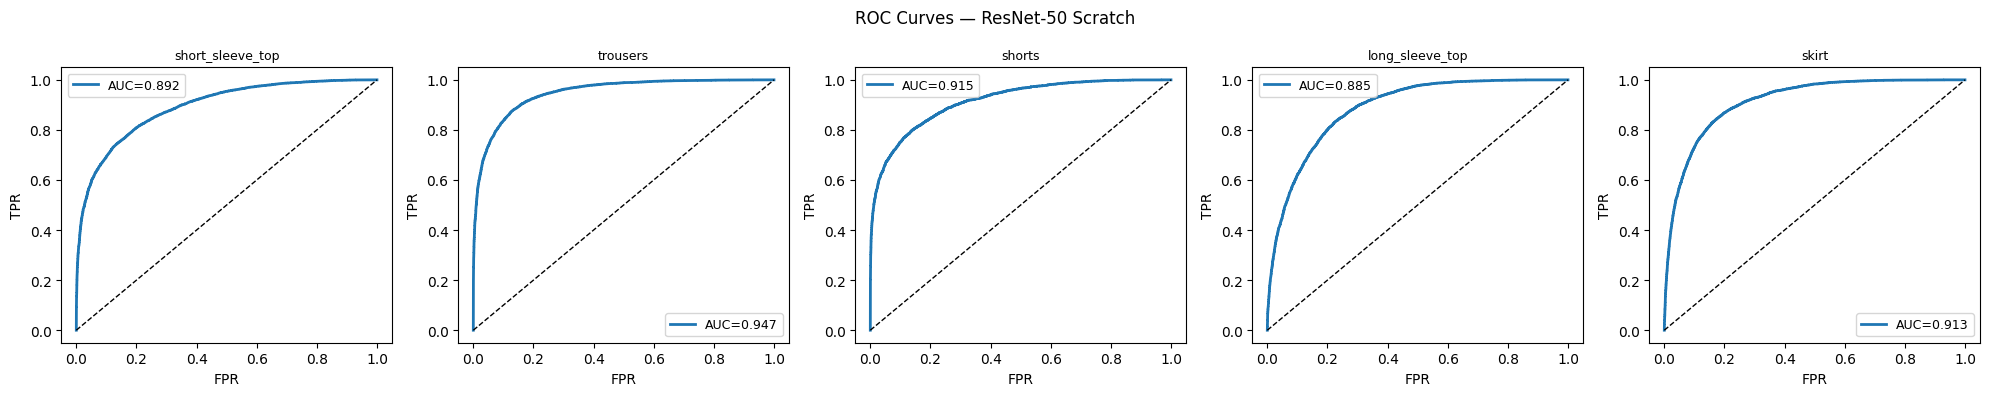

In [32]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={per_class[cls]["AUC"]:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(cls, fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
plt.suptitle('ROC Curves — ResNet-50 Scratch', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Training Curves

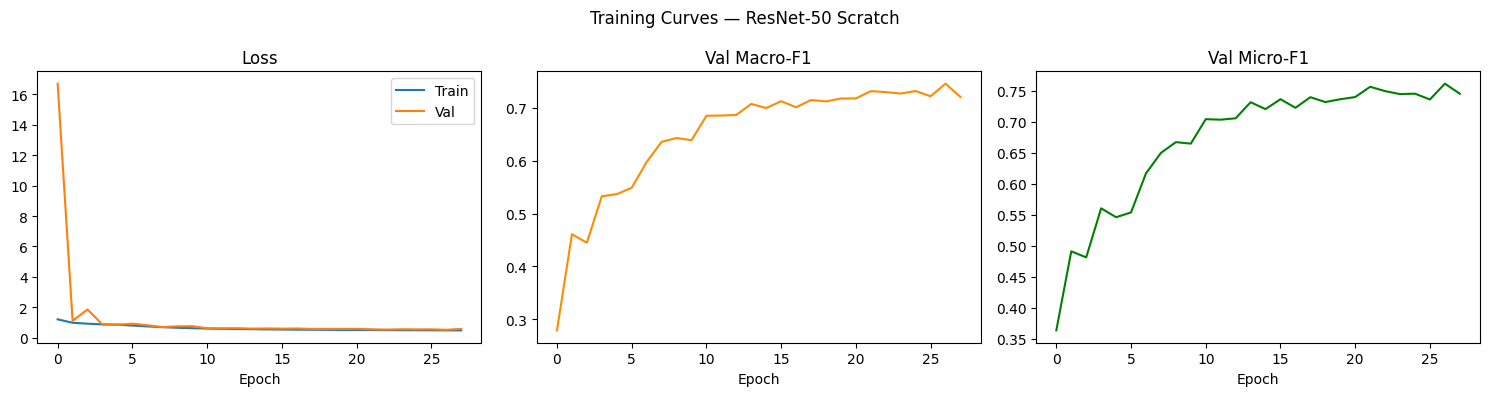

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['macro_f1'], color='darkorange')
axes[1].set_title('Val Macro-F1'); axes[1].set_xlabel('Epoch')

axes[2].plot(history['micro_f1'], color='green')
axes[2].set_title('Val Micro-F1'); axes[2].set_xlabel('Epoch')

plt.suptitle('Training Curves — ResNet-50 Scratch', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/curves_scratch.png', dpi=150, bbox_inches='tight')
plt.show()